In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [8]:
# STEP 1 — DATA PREPARATION
import os, glob, random, numpy as np
from PIL import Image
from tqdm import tqdm
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.utils as vutils

# Project directories
project_root = "/kaggle/working/inpainting_project"
os.makedirs(project_root, exist_ok=True)
eval_root = os.path.join(project_root, "eval_set")
os.makedirs(eval_root, exist_ok=True)
mask_root = os.path.join(eval_root, "masks")
os.makedirs(mask_root, exist_ok=True)
sample_root = os.path.join(project_root, "samples")
os.makedirs(sample_root, exist_ok=True)

print("Working dir:", project_root)

# Path to COCO train images (update if different)
coco_root = "/kaggle/input/coco-2017-dataset/coco2017/train2017"
assert os.path.exists(coco_root), f"COCO root not found: {coco_root}"

all_images = glob.glob(os.path.join(coco_root, "*.jpg"))
all_images.sort()
print("Total images available:", len(all_images))

# Split
EVAL_SIZE = 500
eval_images = all_images[:EVAL_SIZE]
train_images = all_images[EVAL_SIZE:]
print("Eval images:", len(eval_images), "Train images:", len(train_images))

# Save eval list
with open(os.path.join(eval_root, "eval_images.txt"), "w") as f:
    f.write("\n".join(eval_images))
print("Saved eval list.")

# Deterministic eval masks (numpy .npy)
SAFE_IMG_SIZE = 192   # chosen safe resolution (must be used everywhere)
def generate_eval_mask(idx, img_size=SAFE_IMG_SIZE):
    mask = np.zeros((img_size, img_size), dtype=np.float32)
    random.seed(idx)
    size = random.randint(32, 96)
    x = random.randint(0, img_size - size)
    y = random.randint(0, img_size - size)
    mask[y:y+size, x:x+size] = 1.0
    return mask

print("Generating deterministic eval masks...")
for i in tqdm(range(EVAL_SIZE)):
    m = generate_eval_mask(i)
    np.save(os.path.join(mask_root, f"mask_{i}.npy"), m)
print("Masks saved to:", mask_root)

# ---------------------------
# Dataset
# ---------------------------
class CocoInpaintingDataset(Dataset):
    def __init__(self, image_list, img_size=SAFE_IMG_SIZE, min_mask=48, max_mask=96):
        self.images = image_list
        self.img_size = img_size
        self.min_mask = min_mask
        self.max_mask = max_mask
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
        ])

    def random_mask(self, img_size=None, min_size=None, max_size=None):
        if img_size is None:
            img_size = self.img_size
        if min_size is None:
            min_size = self.min_mask
        if max_size is None:
            max_size = self.max_mask
        hole = random.randint(min_size, max_size)
        x = random.randint(0, img_size - hole)
        y = random.randint(0, img_size - hole)
        mask = np.zeros((img_size, img_size), dtype=np.float32)
        mask[y:y+hole, x:x+hole] = 1.0
        mask = torch.from_numpy(mask).unsqueeze(0)  # (1,H,W)
        return mask

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        path = self.images[idx]
        img = Image.open(path).convert("RGB")
        img = self.transform(img)  # tensor (3,H,W) with H,W == self.img_size
        mask = self.random_mask(img_size=self.img_size)  # (1,H,W)
        masked_img = img * (1 - mask)  # broadcast (3,H,W) * (1,H,W)
        return masked_img, img, mask

# Build datasets
train_dataset = CocoInpaintingDataset(train_images, img_size=SAFE_IMG_SIZE)
eval_dataset = CocoInpaintingDataset(eval_images, img_size=SAFE_IMG_SIZE)

print("Train dataset len:", len(train_dataset), "Eval len:", len(eval_dataset))

# Sanity check: load a small batch with num_workers=0 (safer)
from torch.utils.data import DataLoader
loader_test = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=0)
masked_batch, clean_batch, mask_batch = next(iter(loader_test))
print("Example batch shapes (masked,img,mask):", masked_batch.shape, clean_batch.shape, mask_batch.shape)

# Save few sample visuals
for i in range(min(4, masked_batch.size(0))):
    vutils.save_image(masked_batch[i], f"{sample_root}/masked_{i}.png")
    vutils.save_image(clean_batch[i], f"{sample_root}/clean_{i}.png")
    vutils.save_image(mask_batch[i], f"{sample_root}/mask_{i}.png")
print("Saved sample images to:", sample_root)

print("STEP 1 COMPLETE.")


Working dir: /kaggle/working/inpainting_project
Total images available: 118287
Eval images: 500 Train images: 117787
Saved eval list.
Generating deterministic eval masks...


100%|██████████| 500/500 [00:00<00:00, 2993.95it/s]

Masks saved to: /kaggle/working/inpainting_project/eval_set/masks
Train dataset len: 117787 Eval len: 500


Example batch shapes (masked,img,mask): torch.Size([2, 3, 192, 192]) torch.Size([2, 3, 192, 192]) torch.Size([2, 1, 192, 192])
Saved sample images to: /kaggle/working/inpainting_project/samples
STEP 1 COMPLETE.


In [9]:
# STEP 2 — MODELS
import torch
import torch.nn as nn
import torch.nn.functional as F

# Small conv block
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, ks=3, stride=1, pad=1):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, ks, stride, pad)
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

# Generator (UNet-like)
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.e1 = ConvBlock(3, 64)
        self.e2 = ConvBlock(64, 128, stride=2)
        self.e3 = ConvBlock(128, 256, stride=2)
        self.e4 = ConvBlock(256, 512, stride=2)
        self.e5 = ConvBlock(512, 512, stride=2)

        # Bottleneck
        self.b1 = ConvBlock(512, 512)
        self.b2 = ConvBlock(512, 512)

        # Decoder
        self.d1 = nn.ConvTranspose2d(512, 512, 4, stride=2, padding=1)
        self.d2 = nn.ConvTranspose2d(1024, 256, 4, stride=2, padding=1)
        self.d3 = nn.ConvTranspose2d(512, 128, 4, stride=2, padding=1)
        self.d4 = nn.ConvTranspose2d(256, 64, 4, stride=2, padding=1)
        self.d5 = nn.Conv2d(128, 3, 3, padding=1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(e1)
        e3 = self.e3(e2)
        e4 = self.e4(e3)
        e5 = self.e5(e4)

        b = self.b1(e5)
        b = self.b2(b)

        d1 = self.d1(b); d1 = torch.cat([d1, e4], dim=1)
        d2 = self.d2(d1); d2 = torch.cat([d2, e3], dim=1)
        d3 = self.d3(d2); d3 = torch.cat([d3, e2], dim=1)
        d4 = self.d4(d3); d4 = torch.cat([d4, e1], dim=1)

        out = self.d5(d4)
        return torch.sigmoid(out)

# Discriminator (PatchGAN)
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        def disc_block(in_c, out_c, stride=2):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 4, stride=stride, padding=1),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.2, inplace=True)
            )
        self.model = nn.Sequential(
            disc_block(3, 64),
            disc_block(64, 128),
            disc_block(128, 256),
            disc_block(256, 512),
            nn.Conv2d(512, 1, 4, padding=1)
        )
    def forward(self, x):
        return self.model(x)

# quick shape test
G = Generator()
D = Discriminator()
x = torch.randn(2, 3, SAFE_IMG_SIZE, SAFE_IMG_SIZE)
print("Generator output shape:", G(x).shape)
print("Discriminator output shape:", D(x).shape)

print("STEP 2 COMPLETE.")


Generator output shape: torch.Size([2, 3, 192, 192])
Discriminator output shape: torch.Size([2, 1, 11, 11])
STEP 2 COMPLETE.


In [10]:
# STEP 3 — TRAINING LOOP (safe, paste-ready)
import os, time
from tqdm import tqdm
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.utils as vutils
from torch.cuda.amp import autocast, GradScaler
import torch.nn.functional as F
from torch.utils.data import Subset, DataLoader

# Config (tune if needed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_TRAIN_IMAGES = 20000
BATCH_SIZE = 2
NUM_WORKERS = 1
EPOCHS = 6
LR = 2e-4
BETA1, BETA2 = 0.5, 0.999

L1_WEIGHT = 30.0
ADV_WEIGHT = 1.0

USE_PERCEPTUAL = True        # set False to disable LPIPS
PERCEPTUAL_NET = "alex"      # 'alex' is light, 'vgg' is heavy
PERCEPTUAL_DOWNSAMPLE = 128  # LPIPS computed on smaller size

MIN_MASK = 48
MAX_MASK = 96

project_root = "/kaggle/working/inpainting_project"
ckpt_path = os.path.join(project_root, "gan_ckpt_full.pth")
samples_dir = os.path.join(project_root, "samples")
os.makedirs(samples_dir, exist_ok=True)

print("Device:", device, "Batch size:", BATCH_SIZE, "Image size:", SAFE_IMG_SIZE)
print("Perceptual:", USE_PERCEPTUAL, PERCEPTUAL_NET, "downsample:", PERCEPTUAL_DOWNSAMPLE)

# Rebuild dataloader (ensure consistent dataset img_size)
train_dataset.img_size = SAFE_IMG_SIZE
train_dataset.min_mask = MIN_MASK
train_dataset.max_mask = MAX_MASK

subset_indices = list(range(min(len(train_dataset), MAX_TRAIN_IMAGES)))
train_subset = Subset(train_dataset, subset_indices)
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, drop_last=True, pin_memory=True)

print("Reduced train size:", len(train_subset), "Batches/epoch:", len(train_loader))

# Models, optimizers, losses
G = Generator().to(device)
D = Discriminator().to(device)

opt_G = optim.Adam(G.parameters(), lr=LR, betas=(BETA1, BETA2))
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(BETA1, BETA2))

bce_loss = nn.BCEWithLogitsLoss().to(device)
l1_loss = nn.L1Loss().to(device)

# LPIPS init
perceptual_loss_fn = None
if USE_PERCEPTUAL:
    try:
        import lpips
        perceptual_loss_fn = lpips.LPIPS(net=PERCEPTUAL_NET, spatial=False).to(device)
        perceptual_loss_fn.eval()
        print("LPIPS ready:", PERCEPTUAL_NET)
    except Exception as e:
        print("LPIPS init failed, disabling perceptual. Error:", e)
        USE_PERCEPTUAL = False
        perceptual_loss_fn = None

scaler_G = GradScaler(enabled=(device.type == "cuda"))
scaler_D = GradScaler(enabled=(device.type == "cuda"))

# Resume checkpoint if available
start_epoch = 0
if os.path.exists(ckpt_path):
    ck = torch.load(ckpt_path, map_location=device)
    G.load_state_dict(ck.get("G_state", {}))
    D.load_state_dict(ck.get("D_state", {}))
    opt_G.load_state_dict(ck.get("optG_state", {}))
    opt_D.load_state_dict(ck.get("optD_state", {}))
    start_epoch = ck.get("epoch", 0) + 1
    print("Resumed from epoch", start_epoch)

# Small helper: save sample images
def save_samples(epoch, n=4):
    G.eval()
    with torch.no_grad():
        try:
            sample = next(iter(train_loader))
        except StopIteration:
            return
        masked = sample[0].to(device)
        real = sample[1].to(device)
        fake = G(masked)
        def to_uint8_batch(t):
            t = t.detach().cpu().clamp(0,1).numpy()
            t = (t*255).astype(np.uint8)
            t = np.transpose(t, (0,2,3,1))
            return t
        r = to_uint8_batch(real); m = to_uint8_batch(masked); f = to_uint8_batch(fake)
        for i in range(min(n, len(r))):
            concat = np.concatenate([r[i], m[i], f[i]], axis=1)
            Image.fromarray(concat).save(os.path.join(samples_dir, f"ep{epoch}_s{i}.png"))
    G.train()

# Optional: quick single-batch test to confirm shapes and memory
def single_batch_check():
    batch = next(iter(train_loader))
    masked, real, mask = batch
    print("Batch shapes:", masked.shape, real.shape, mask.shape)
    if device.type == "cuda":
        import torch
        print("CUDA available:", torch.cuda.is_available())
        print("mem_alloc(MB):", torch.cuda.memory_allocated()/1024**2, "mem_reserved(MB):", torch.cuda.memory_reserved()/1024**2)

single_batch_check()

# TRAIN LOOP (safe handling for OOM)
print("Starting training...")
for epoch in range(start_epoch, EPOCHS):
    G.train(); D.train()
    running_G = 0.0; running_D = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}]")
    iter_idx = 0
    for batch in pbar:
        iter_idx += 1
        try:
            masked_img = batch[0].to(device, non_blocking=True)
            real_img   = batch[1].to(device, non_blocking=True)
            mask       = batch[2].to(device, non_blocking=True)

            # -----------------------
            # Discriminator step
            # -----------------------
            opt_D.zero_grad(set_to_none=True)
            with autocast(enabled=(device.type=='cuda')):
                out_real = D(real_img)
                with torch.no_grad():
                    fake_for_d = G(masked_img)
                out_fake = D(fake_for_d)
                loss_D = 0.5 * (bce_loss(out_real, torch.ones_like(out_real)) +
                                bce_loss(out_fake, torch.zeros_like(out_fake)))
            scaler_D.scale(loss_D).backward()
            scaler_D.unscale_(opt_D)
            torch.nn.utils.clip_grad_norm_(D.parameters(), 5.0)
            scaler_D.step(opt_D); scaler_D.update()

            # -----------------------
            # Generator step
            # -----------------------
            opt_G.zero_grad(set_to_none=True)
            with autocast(enabled=(device.type=='cuda')):
                fake_img = G(masked_img)
                adv_loss = bce_loss(D(fake_img), torch.ones_like(out_fake))

                mask3 = mask.repeat(1,3,1,1)
                rec_loss = l1_loss(fake_img * mask3, real_img * mask3)

                loss_G = ADV_WEIGHT * adv_loss + L1_WEIGHT * rec_loss

                if USE_PERCEPTUAL and perceptual_loss_fn is not None:
                    small_fake = F.interpolate(fake_img, size=(PERCEPTUAL_DOWNSAMPLE, PERCEPTUAL_DOWNSAMPLE), mode='bilinear', align_corners=False)
                    small_real = F.interpolate(real_img, size=(PERCEPTUAL_DOWNSAMPLE, PERCEPTUAL_DOWNSAMPLE), mode='bilinear', align_corners=False)
                    lpips_val = perceptual_loss_fn(small_fake, small_real).mean()
                    loss_G = loss_G + lpips_val

            scaler_G.scale(loss_G).backward()
            scaler_G.unscale_(opt_G)
            torch.nn.utils.clip_grad_norm_(G.parameters(), 5.0)
            scaler_G.step(opt_G); scaler_G.update()

            running_G += float(loss_G.detach().cpu().item())
            running_D += float(loss_D.detach().cpu().item())

            if iter_idx % 50 == 0:
                if device.type == "cuda":
                    mem_alloc = torch.cuda.memory_allocated()/1024**2
                    mem_res  = torch.cuda.memory_reserved()/1024**2
                    pbar.set_postfix({"loss_D": f"{loss_D.item():.4f}", "loss_G": f"{loss_G.item():.4f}",
                                      "mem_alloc(MB)": f"{mem_alloc:.0f}", "mem_res(MB)": f"{mem_res:.0f}"})
                else:
                    pbar.set_postfix({"loss_D": f"{loss_D.item():.4f}", "loss_G": f"{loss_G.item():.4f}"})

        except RuntimeError as e:
            s = str(e).lower()
            if "out of memory" in s or "cuda" in s:
                print("\n⚠️  Caught CUDA OOM — clearing cache and skipping batch.")
                torch.cuda.empty_cache()
                continue
            else:
                raise

    epoch_time = time.time() - epoch_start if 'epoch_start' in locals() else 0
    avg_G = running_G / max(1, len(train_loader))
    avg_D = running_D / max(1, len(train_loader))
    print(f"Epoch {epoch+1} finished — avg_G: {avg_G:.4f}, avg_D: {avg_D:.4f}")

    # save samples and checkpoint
    save_samples(epoch+1, n=4)
    torch.save({
        "epoch": epoch,
        "G_state": G.state_dict(),
        "D_state": D.state_dict(),
        "optG_state": opt_G.state_dict(),
        "optD_state": opt_D.state_dict()
    }, ckpt_path)
    print("Saved checkpoint:", ckpt_path)

    # free caches
    if device.type == "cuda":
        torch.cuda.empty_cache()

print("Training finished.")


Device: cuda Batch size: 2 Image size: 192
Perceptual: True alex downsample: 128
Reduced train size: 20000 Batches/epoch: 10000
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.11/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS ready: alex


/tmp/ipykernel_130/2235067018.py:76: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_G = GradScaler(enabled=(device.type == "cuda"))
/tmp/ipykernel_130/2235067018.py:77: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_D = GradScaler(enabled=(device.type == "cuda"))


Batch shapes: torch.Size([2, 3, 192, 192]) torch.Size([2, 3, 192, 192]) torch.Size([2, 1, 192, 192])
CUDA available: True
mem_alloc(MB): 91.4755859375 mem_reserved(MB): 210.0
Starting training...


Epoch [1/6]:   0%|          | 0/10000 [00:00<?, ?it/s]/tmp/ipykernel_130/2235067018.py:142: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type=='cuda')):
/tmp/ipykernel_130/2235067018.py:158: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type=='cuda')):
Epoch [1/6]: 100%|██████████| 10000/10000 [07:32<00:00, 22.10it/s, loss_D=0.6412, loss_G=1.8586, mem_alloc(MB)=341, mem_res(MB)=558]

Epoch 1 finished — avg_G: 1.6347, avg_D: 0.6808


...

Epoch 5 finished — avg_G: 1.6409, avg_D: 0.6496


Saved checkpoint: /kaggle/working/inpainting_project/gan_ckpt_full.pth


Epoch [6/6]: 100%|██████████| 10000/10000 [07:39<00:00, 21.75it/s, loss_D=0.7051, loss_G=1.4583, mem_alloc(MB)=344, mem_res(MB)=558]

Epoch 6 finished — avg_G: 1.6685, avg_D: 0.6431


Saved checkpoint: /kaggle/working/inpainting_project/gan_ckpt_full.pth
Training finished.


In [11]:
# A — Inference on eval set + metrics
import os, math
from tqdm import tqdm
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
import torchvision.utils as vutils

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path = os.path.join(project_root, "gan_ckpt_full.pth")
out_dir = os.path.join(project_root, "eval_results")
os.makedirs(out_dir, exist_ok=True)

# load model
G = Generator().to(device)
ck = torch.load(ckpt_path, map_location=device)
G.load_state_dict(ck.get("G_state", G.state_dict()))
G.eval()
print("Loaded G from:", ckpt_path)

# Setup LPIPS if available
use_lpips = True
try:
    import lpips
    lpips_fn = lpips.LPIPS(net='alex').to(device)
    lpips_fn.eval()
except Exception as e:
    print("LPIPS not available, skipping LPIPS metric:", e)
    lpips_fn = None
    use_lpips = False

def psnr_from_mse(mse):
    return 10 * math.log10(1.0 / (mse + 1e-12))

# dataloader for eval
from torch.utils.data import DataLoader
eval_loader = DataLoader(eval_dataset, batch_size=4, shuffle=False, num_workers=0)

lpips_vals = []
psnr_vals = []
mse_vals = []

with torch.no_grad():
    for i, batch in enumerate(tqdm(eval_loader, desc="Eval")):
        masked, real, mask = batch
        masked = masked.to(device)
        real = real.to(device)
        # forward
        fake = G(masked)
        # clamp to [0,1]
        fake = fake.clamp(0,1)

        # metrics per image
        # MSE & PSNR
        mse_batch = torch.mean((fake - real) ** 2, dim=[1,2,3]).cpu().numpy()
        for m in mse_batch:
            mse_vals.append(float(m))
            psnr_vals.append(psnr_from_mse(m))

        # LPIPS
        if use_lpips and lpips_fn is not None:
            # LPIPS expects NCHW, values in [-1,1] for some versions — lpips wrapper handles [0,1] too
            lp = lpips_fn(fake, real)
            # lp shape maybe (N,1,1,1) or (N,1)
            lp = lp.reshape(lp.shape[0]).cpu().numpy()
            lpips_vals.extend([float(x) for x in lp])

        # save side-by-side images (first batch crop)
        bs = fake.shape[0]
        for j in range(bs):
            r = (real[j].cpu().numpy().transpose(1,2,0) * 255).astype(np.uint8)
            msk = (masked[j].cpu().numpy().transpose(1,2,0) * 255).astype(np.uint8)
            f = (fake[j].cpu().numpy().transpose(1,2,0) * 255).astype(np.uint8)
            concat = np.concatenate([r, msk, f], axis=1)
            Image.fromarray(concat).save(os.path.join(out_dir, f"eval_{i*bs + j:04d}.png"))

# Summarize
print("Eval images saved to:", out_dir)
print("PSNR  mean:", np.mean(psnr_vals), "std:", np.std(psnr_vals))
print("MSE   mean:", np.mean(mse_vals), "std:", np.std(mse_vals))
if use_lpips and len(lpips_vals)>0:
    print("LPIPS mean:", np.mean(lpips_vals), "std:", np.std(lpips_vals))
else:
    print("LPIPS skipped.")


Loaded G from: /kaggle/working/inpainting_project/gan_ckpt_full.pth
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.11/dist-packages/lpips/weights/v0.1/alex.pth


Eval: 100%|██████████| 125/125 [00:30<00:00,  4.05it/s]

Eval images saved to: /kaggle/working/inpainting_project/eval_results
PSNR  mean: 21.005489408048664 std: 2.4758697063906694
MSE   mean: 0.009263660793891177 std: 0.0052777791252531635
LPIPS mean: 0.15137726458907128 std: 0.050081795287066334


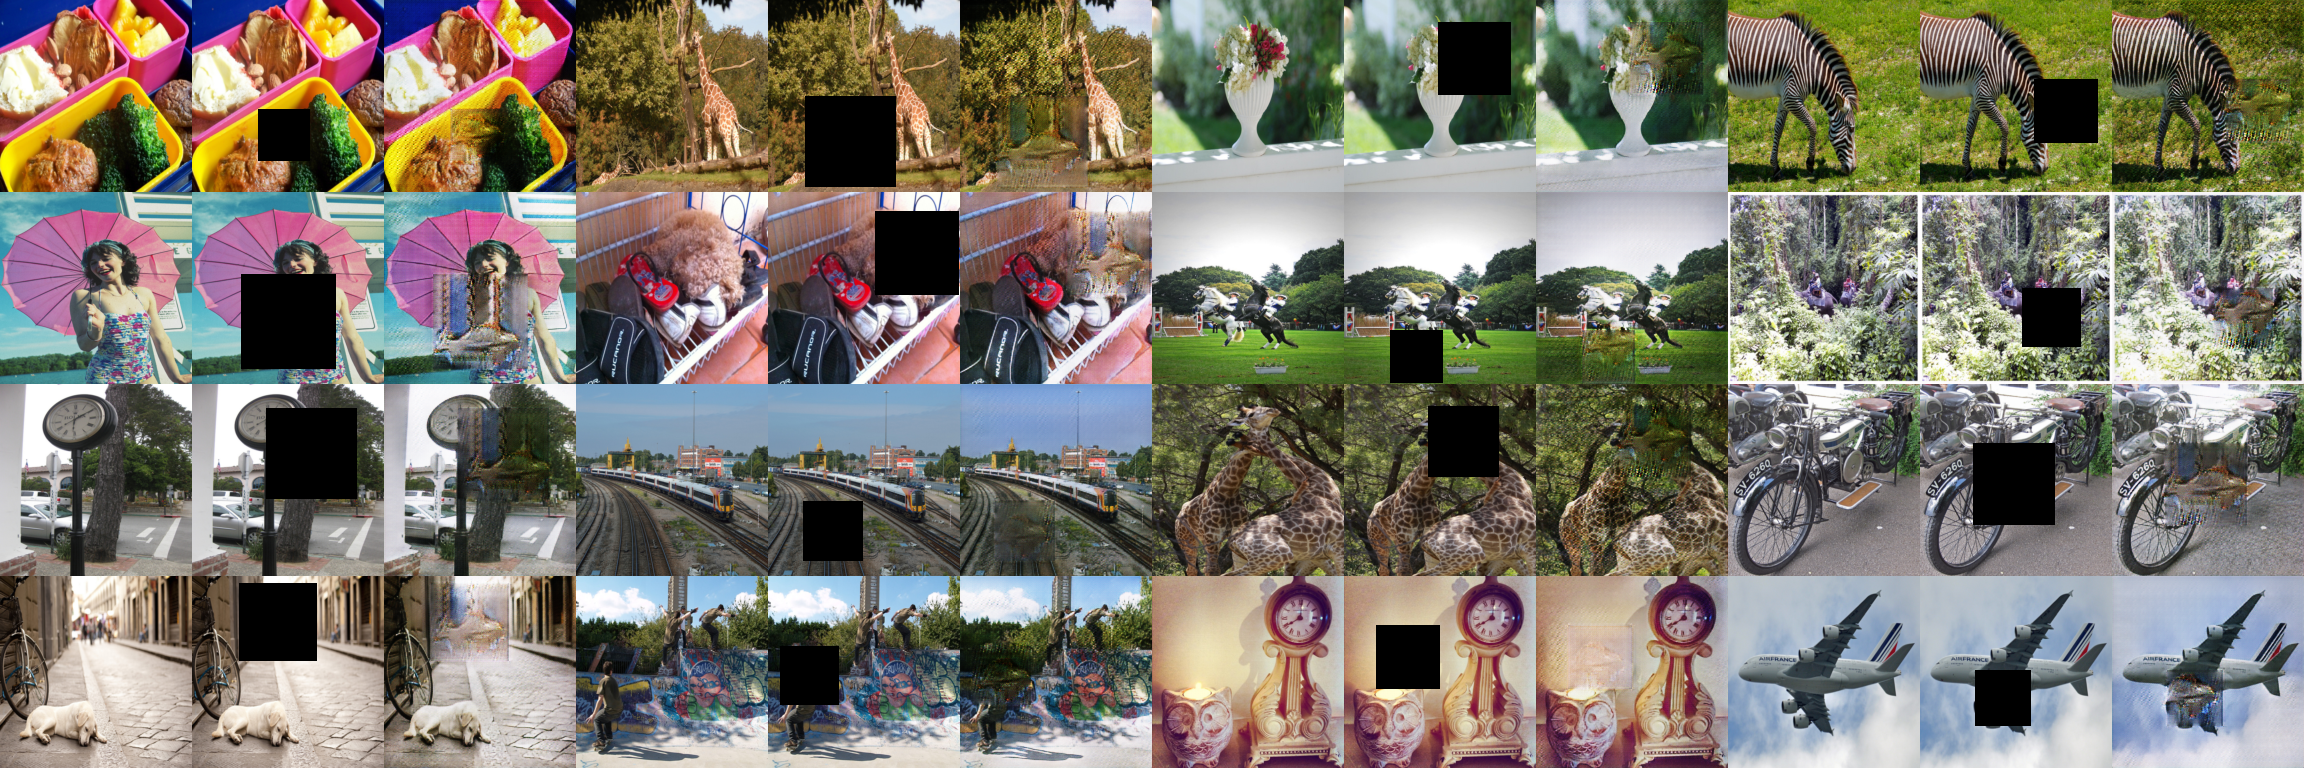

In [12]:
# B — display a grid of saved eval images inline (first 16)
from IPython.display import display, Image as IPyImage
import glob
imgs = sorted(glob.glob(os.path.join(out_dir, "eval_*.png")))
grid = imgs[:16]
# make a grid image using torchvision
pil_images = [Image.open(p) for p in grid]
w, h = pil_images[0].size
cols = 4
rows = math.ceil(len(pil_images)/cols)
grid_img = Image.new('RGB', (w*cols, h*rows), color=(255,255,255))
for idx, img in enumerate(pil_images):
    x = (idx % cols) * w
    y = (idx // cols) * h
    grid_img.paste(img, (x,y))
grid_path = os.path.join(out_dir, "grid_preview.png")
grid_img.save(grid_path)
display(IPyImage(grid_path))


In [38]:
import torch

# Assuming G and D are your trained generator and discriminator
checkpoint_path = "/kaggle/working/baseline_gan_checkpoint.pth"

torch.save({
    'gen_state_dict': G.state_dict(),
    'disc_state_dict': D.state_dict()
}, checkpoint_path)

print(f"Checkpoint saved at: {checkpoint_path}")


Checkpoint saved at: /kaggle/working/baseline_gan_checkpoint.pth


In [41]:
!ls /kaggle/input/baseline-gan-checkpoint-trained


baseline_gan_checkpoint.pth
